In [2]:
import sys, os
sys.path.append('..')

In [3]:
from src.slices_pipeline.encoder import *
from src.slices_pipeline.loader import *
from slices.core import SLICES

Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


In [4]:
!cd .. && ./apply_patch.sh && cd -

/root/Crystal-generator-using-SLICES/notebooks


In [5]:
backend = SLICES(relax_model="chgne")

In [ ]:
from transformers import GPT2TokenizerFast, GPT2LMHeadModel
import torch

def infernece(checkpoint_path="finetune_gpt2_slices/checkpoint-4800", save_file="generated_slices.txt", num_samples=5):
    CHECKPOINT_DIR = f"checkpoints/{checkpoint_path}"

    tokenizer = GPT2TokenizerFast.from_pretrained(CHECKPOINT_DIR)
    model     = GPT2LMHeadModel.from_pretrained(CHECKPOINT_DIR)

    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token

    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # prompt_bg = "<BG_0.0>"
    prompt_bg = "<BG_1.4>"
    # prompt_fe = "<FE_-0.7>"
    prompt_fe = "<FE_-1.6>"

    prompt = "<BOS> " + prompt_bg + " " + prompt_fe + " |"

    encoded = tokenizer(
        prompt,
        return_tensors="pt",
        padding=False,
        truncation=False
    )
    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    max_length = 300
    num_samples = num_samples
    do_sample = True
    top_p = 0.9
    top_k = 50
    temperature = 0.7

    eos_id = tokenizer.eos_token_id

    outputs = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,

        max_length=max_length,
        do_sample=do_sample,
        top_p=top_p,
        top_k=top_k,
        temperature=temperature,
        num_return_sequences=num_samples,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=eos_id,
    )

    with open(save_file, "w", encoding="utf-8") as fout:
        for i, out_ids in enumerate(outputs):
            generated = tokenizer.decode(out_ids, skip_special_tokens=False)
            print(f"\n=== Sample #{i+1} ===")
            print(generated)
            fout.write(f"\n=== Sample #{i+1} ===\n")
            fout.write(str(generated) + "\n")
            if "<EOS>" in generated:
                generated = generated.split("<EOS>")[0] + "<EOS>"
                print("--- Структура до <EOS> ---")
                print(generated)
                fout.write("--- Структура до <EOS> ---\n")
                fout.write(str(generated) + "\n")

            if "|" in generated:
                parts = generated.split("|", 1)
                slices_str = parts[1]
                slices_str = slices_str.replace("<EOS>", "").strip()
                print("--- SLICES-строка ---")
                print(slices_str)
                fout.write("--- SLICES-строка ---\n")
                fout.write(str(slices_str) + "\n")

                try:
                    backend.SLICES2structure(slices_str)
                    print("SUCCESS!")
                    fout.write("SUCCESS!\n")
                except Exception as e:
                    print("FAIL!", e)
                    fout.write("FAIL! " + str(e) + "\n")

In [13]:
# infernece(checkpoint_path="finetune_gpt2_slices_3/checkpoint-1800", save_file="test-inference.txt")
# infernece(checkpoint_path="finetune_gpt2_slices_4/checkpoint-1800", save_file="test-inference.txt", num_samples=20)
infernece(checkpoint_path="finetune_gpt2_slices_5/checkpoint-1800", save_file="failed-tune.txt", num_samples=5)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.



=== Sample #1 ===
<BOS> <BG_1.4> <FE_-1.6> | Tb Tb Tb Tb Tb Tb Mg Mg Se Se Se Se Se Se Se Se Se Se Se Se 0 15 -oo 0 15 ooo 0 11 -+o 0 11 o+o 0 16 ooo 0 18 o+o 1 10 o-o 1 10 +-o 1 14 ooo 1 14 +oo 1 19 ooo 1 17 ooo 2 13 -oo 2 13 ooo 2 9 -o+ 2 9 oo+ 2 17 -+o 2 17 o+o 2 18 o+o 3 16 o-o 3 16 +-o 3 12 ooo 3 12 +oo 3 8 o-o 3 19 ooo 4 8 -oo 4 8 ooo 4 13 -oo 4 13 ooo 4 11 -oo 4 11 ooo 4 12 ooo 4 16 ooo 5 14 ooo 5 14 +oo 5 10 ooo 5 10 +oo 5 9 ooo 5 17 ooo 5 13 ooo 6 19 -oo 6 19 ooo 6 18 ooo 6 8 o-o 6 14 ooo 6 15 ooo 7 12 ooo 7 12 +oo 7 18 ooo 7 18 +oo 7 9 ooo 7 15 ooo 7 19 ooo <EOS><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|en

In [13]:
from transformers import GPT2TokenizerFast, GPT2LMHeadModel

CHECKPOINT_DIR = "checkpoints/finetune_gpt2_slices/checkpoint-4000"
tok = GPT2TokenizerFast.from_pretrained(CHECKPOINT_DIR)
mdl = GPT2LMHeadModel.from_pretrained(CHECKPOINT_DIR)

print("Tokenizer vocab size:", len(tok))
print("Model embedding size:", mdl.get_input_embeddings().weight.shape[0])

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Tokenizer vocab size: 50461
Model embedding size: 50461


In [16]:
# s = 'Ba Ba Ba Ba In In In In Ge Ge Ge Ge Ge Ge Ge Ge 0 6 o o o 0 6 + o o 0 10 o o o 0 10 + o o 0 15 o o o 0 15 + o o 0 5 o o o 0 5 + o o 0 8 o o o 0 12 o o o 0 13 o o o 0 9 o o o 0 7 o o o 1 4 o o o 1 4 + o o 1 12 o - o 1 13 o - o 1 13 + - o 1 11 o o o 1 11 + o o 1 14 o o o 1 14 + o o 1 8 o o o 1 9 o - o 1 7 o - o 1 6 + o o 1 10 + o o 2 13 o - - 2 12 - - o 2 12 o - o 2 9 - - - 2 9 o - - 2 11 o o - 2 14 o o o 2 14 + o o 2 7 - - - 2 6 o o o 2 8 o o - 2 15 o o o 3 14 o o o 3 14 + o o 3 11 o o o 3 11 + o o 3 10 o o o 3 10 + o o 3 15 o o o 3 15 + o o 3 7 o - o 3 8 o o o 3 9 o o o 3 6 + o o 3 13 + o o 4 15 o o o 4 8 - o o 4 8 o o o 4 6'
s = 'Rb Rb Rb Rb Rb Rb Mg Mg H H H H H H H H H H 0 11 -oo 0 10 -oo 0 14 ooo 0 17 o++ 0 15 ooo 0 16 oo+ 0 12 o++ 0 9 oo+ 1 13 oo- 1 8 o-- 1 16 ooo 1 11 ooo 1 17 +oo 1 10 ooo 1 15 +oo 1 14 +oo 2 16 ooo 2 9 ooo 2 13 o+o 2 12 o+o 2 8 ooo 2 14 +oo 2 11 ooo 2 17 +++ 3 17 ooo 3 15 ooo 3 10 -oo 3 12 ooo 3 9 o-o 3 8 o-o 3 13 ooo 3 16 oo+ 4 14 o-- 4 10 -o- 4 17 ooo 4 13 -o- 4 15 ooo 4 9 ooo 4 8 o-- 4 12 ooo 4 16 ooo 4 11 ooo 5 15 oo- 5 16 ooo 5 8 oo- 5 12 o+o 5 13 oo- 5 11 oo- 5 9 +oo 5 17 ++o 5 14 +oo 5 10 o+o 6 9 ooo 6 14 ooo 6 15 ooo 6 8 ooo 7 12 ooo 7 11 ooo 7 10 ooo 7 13 ooo '
backend.SLICES2structure(s)
# backend.SLICES2structure('Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li Li 0 14 o o o 0 15 o o o 0 16 o o o 0 18 o o o 0 19 o o o 0 17 o o o 0 19 o o + 0 18 o o + 0 18 o + o 0 17 o + o 0 18 + o o 0 17 + o + 0 17 + + + 0 10 o o o 0 16 o o + 0 19 o o + 0 18 + o + 0 17 + + o 0 16 + o + 0 19 + o + 0 17 + + + 0 8 o o o 0 15 o o + 1 19 o - o 1 16 o - o 1 16 o o o 1 18 o o o 1 18 o o + 1 18 + - o 1 18 + o o 1 17 o o o 1 19 o o o 1 15 o - o 1 15 o o o 1 18 + o o 1 17 + o o 1 16 + - o 1 16 + o o 1 18 + o + 1 9 o o o 1 14 o o o 1 13 o o o 2 17 o o o 2 19 o o o 2 19 o o + 2 16 o o o 2 16 + o o 2 18 o o o 2 18 + o o 2 18 + o + 2 15 o')

Relax Error: 'SLICES' object has no attribute 'relaxer'


(Structure Summary
 Lattice
     abc : 7.275472075501385 7.275472075501395 7.28278808689375
  angles : 126.57624803123684 126.57624803123663 78.87311166381298
  volume : 240.62939913436296
       A : 7.275472075501385 0.0 0.0
       B : 1.4040384707107179 7.138709259674671 0.0
       C : -4.339755273106077 -3.569354629837375 4.633058818384247
     pbc : True True True
 PeriodicSite: Rb (0.0, 0.0, 0.0) [0.0, 0.0, 0.0]
 PeriodicSite: Rb (0.01392, 0.01145, -2.702) [-0.29, -0.29, -0.5832]
 PeriodicSite: Rb (0.8677, -1.04, 3.309) [0.5045, 0.2114, 0.7143]
 PeriodicSite: Rb (-0.8534, 1.052, 3.309) [0.2114, 0.5045, 0.7143]
 PeriodicSite: Rb (-0.6976, -3.576, 0.9729) [0.1058, -0.3959, 0.21]
 PeriodicSite: Rb (-3.643, 0.005589, 0.9729) [-0.3959, 0.1058, 0.21]
 PeriodicSite: Mg (-2.237, -1.84, 3.348) [0.1037, 0.1037, 0.7227]
 PeriodicSite: Mg (-2.243, -1.845, -1.398) [-0.4093, -0.4093, -0.3017]
 PeriodicSite: H (-1.344, -1.106, -4.504) [-0.641, -0.641, -0.9721]
 PeriodicSite: H (-1.35, -1.111, 1.

/tmp/ipykernel_255672/1739225356.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot([df[df['success']==1]['slices_length'], df[df['success']==0]['slices_length']],


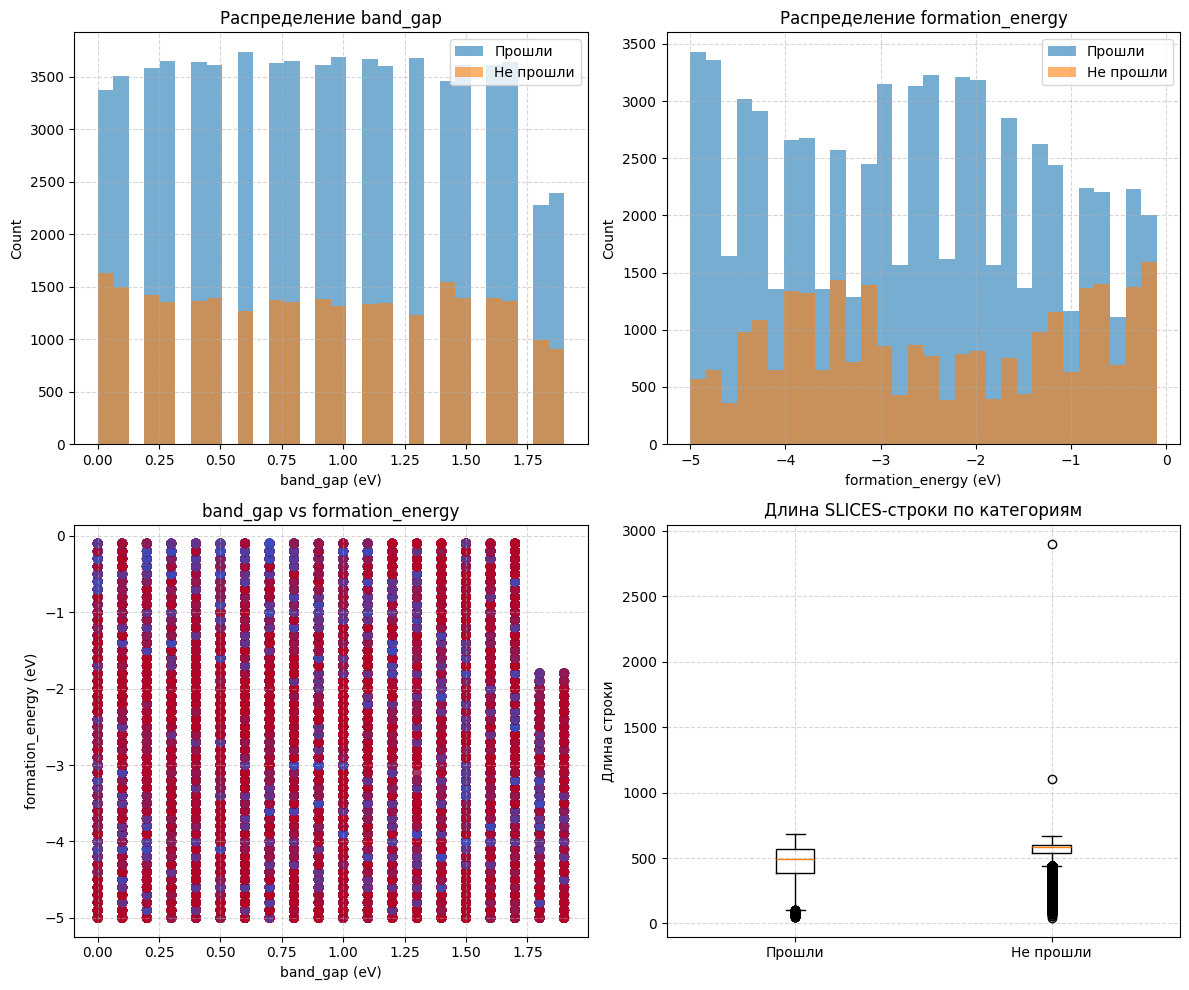

/tmp/ipykernel_255672/1739225356.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  success_rate_bg = df.groupby('band_bin')['success'].mean()


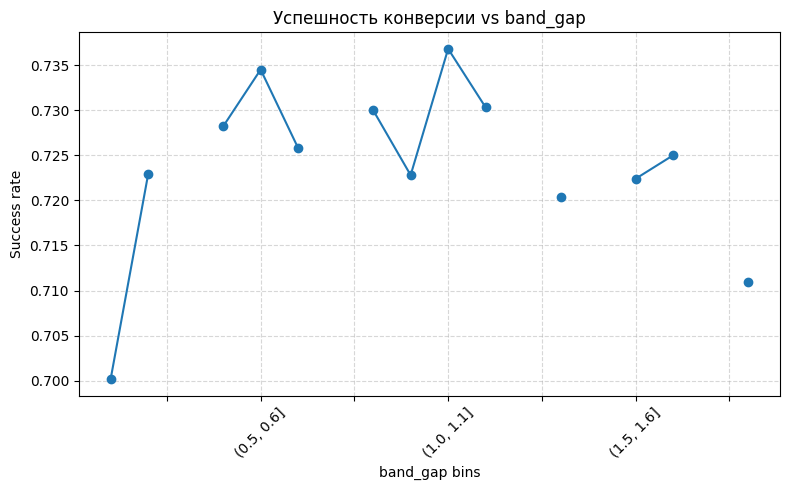

/tmp/ipykernel_255672/1739225356.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  success_rate_fe = df.groupby('fe_bin')['success'].mean()


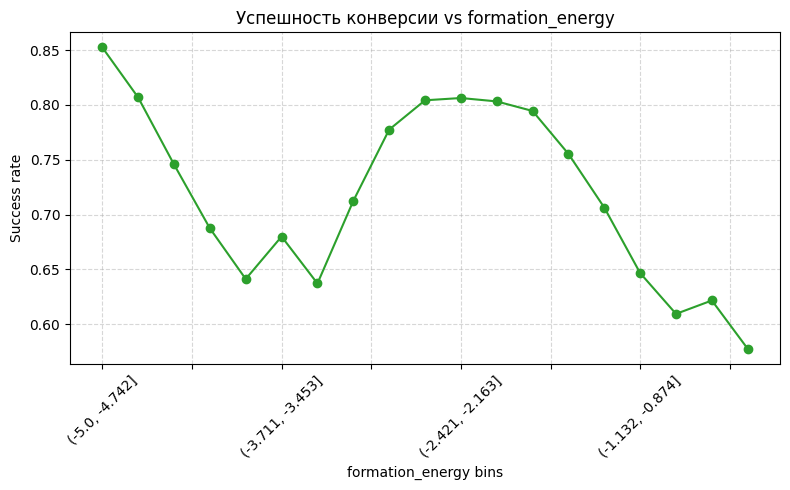

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('inference-results/results.csv', header=None, usecols=[0,1,2,3],
                 names=['success', 'band_gap', 'formation_energy', 'slices_string'])

df['slices_length'] = df['slices_string'].str.len()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0,0].hist(df[df['success']==1]['band_gap'], bins=30, alpha=0.6, label='Прошли', color='C0')
axes[0,0].hist(df[df['success']==0]['band_gap'], bins=30, alpha=0.6, label='Не прошли', color='C1')
axes[0,0].set_title('Распределение band_gap')
axes[0,0].set_xlabel('band_gap (eV)')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()
axes[0,0].grid(True, linestyle='--', alpha=0.5)

axes[0,1].hist(df[df['success']==1]['formation_energy'], bins=30, alpha=0.6, label='Прошли', color='C0')
axes[0,1].hist(df[df['success']==0]['formation_energy'], bins=30, alpha=0.6, label='Не прошли', color='C1')
axes[0,1].set_title('Распределение formation_energy')
axes[0,1].set_xlabel('formation_energy (eV)')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()
axes[0,1].grid(True, linestyle='--', alpha=0.5)

axes[1,0].scatter(df['band_gap'], df['formation_energy'], c=df['success'], cmap='coolwarm', alpha=0.6)
axes[1,0].set_title('band_gap vs formation_energy')
axes[1,0].set_xlabel('band_gap (eV)')
axes[1,0].set_ylabel('formation_energy (eV)')
axes[1,0].grid(True, linestyle='--', alpha=0.5)

axes[1,1].boxplot([df[df['success']==1]['slices_length'], df[df['success']==0]['slices_length']],
                  labels=['Прошли', 'Не прошли'])
axes[1,1].set_title('Длина SLICES-строки по категориям')
axes[1,1].set_ylabel('Длина строки')
axes[1,1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

band_bins = np.linspace(df['band_gap'].min(), df['band_gap'].max(), 20)
df['band_bin'] = pd.cut(df['band_gap'], bins=band_bins)
success_rate_bg = df.groupby('band_bin')['success'].mean()

plt.figure(figsize=(8,5))
success_rate_bg.plot(marker='o')
plt.title('Успешность конверсии vs band_gap')
plt.xlabel('band_gap bins')
plt.ylabel('Success rate')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fe_bins = np.linspace(df['formation_energy'].min(), df['formation_energy'].max(), 20)
df['fe_bin'] = pd.cut(df['formation_energy'], bins=fe_bins)
success_rate_fe = df.groupby('fe_bin')['success'].mean()

plt.figure(figsize=(8,5))
success_rate_fe.plot(marker='o', color='C2')
plt.title('Успешность конверсии vs formation_energy')
plt.xlabel('formation_energy bins')
plt.ylabel('Success rate')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
